In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
X= np.array([1,3,4,6,7])
y = np.array([15, 35, 45, 65, 75])

<Axes: >

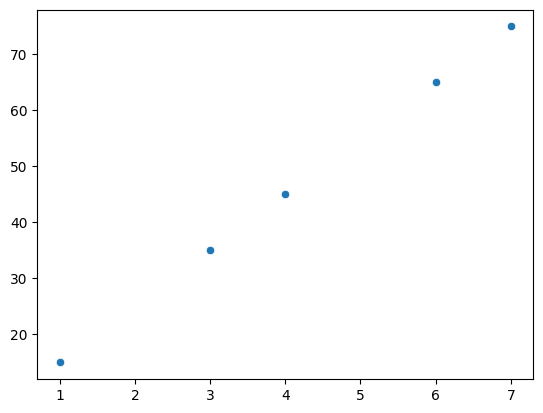

In [3]:
sns.scatterplot(x=X,y=y)

In [4]:
def make_prediction(X,y,w,b):
    m = X.shape[0]
    pred_list=np.zeros((m,))
    for i in range(m):
        pred_list[i] = w*X[i] + b
    return pred_list
        

[0. 0. 0. 0. 0.]


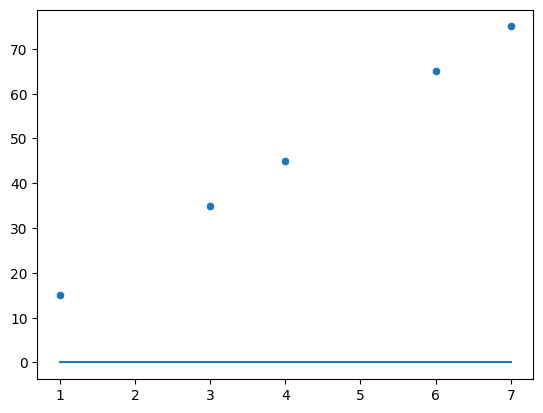

In [5]:
prediction = make_prediction(X,y,0,0)
print(prediction)
sns.scatterplot(x=X,y=y)
plt.plot(X,prediction)

[1. 3. 4. 6. 7.]


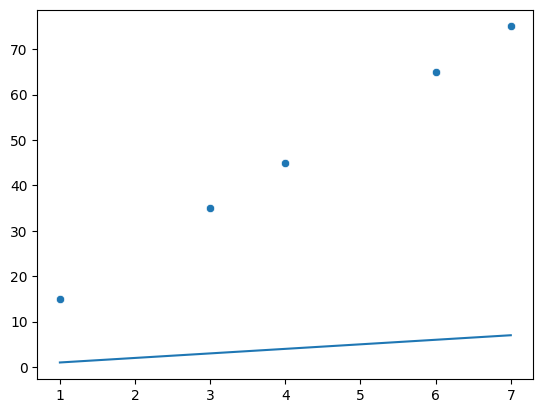

In [6]:
prediction = make_prediction(X,y,1,0)
print(prediction)
sns.scatterplot(x=X,y=y)
plt.plot(X,prediction)

[2. 4. 5. 7. 8.]


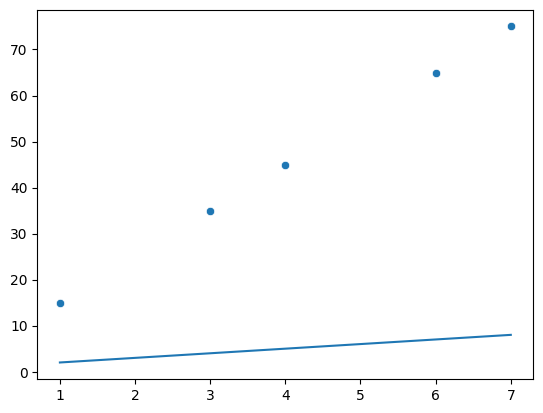

In [7]:
prediction = make_prediction(X,y,1,1)
print(prediction)
sns.scatterplot(x=X,y=y)
plt.plot(X,prediction)

[ 8. 18. 23. 33. 38.]


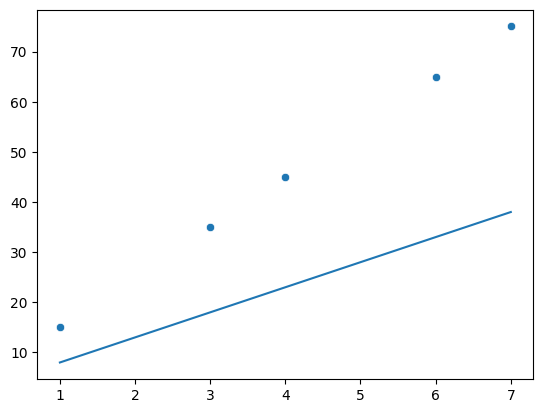

In [8]:
prediction = make_prediction(X,y,5,3)
print(prediction)
sns.scatterplot(x=X,y=y)
plt.plot(X,prediction)

[15. 35. 45. 65. 75.]


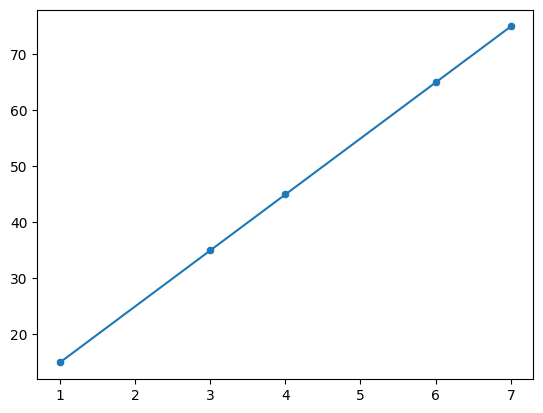

In [9]:
prediction = make_prediction(X,y,10,5)
print(prediction)
sns.scatterplot(x=X,y=y)
plt.plot(X,prediction)

## Cost Function

In [31]:
def compute_cost(X, y, w, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy"""
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i] # Difference between prediction and actual value
    error_squared = error ** 2
    cost = cost + error_squared

  # We divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

In [33]:
result = cost_function(X,y,10,5)
print(result)

[740. 300. 230. 390. 620.]


## Visualization Cost function

Text(0.5, 1.0, 'Cost =1332.5,for w=0.0, b=0.0')

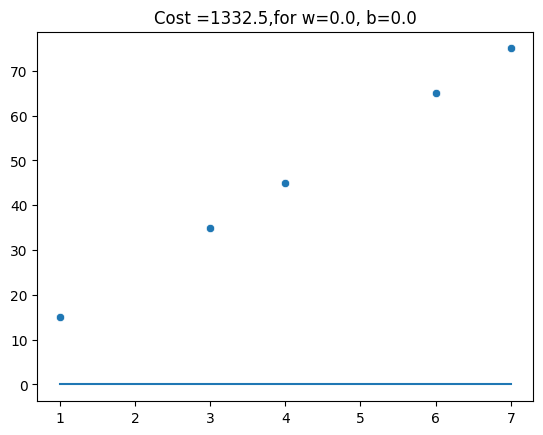

In [34]:
w= 0.0
b=0.0
prediction = make_prediction(X,y,w=w,b=b)

sns.scatterplot(x=X, y=y)
plt.plot(X,prediction)
plt.title(f"Cost ={ compute_cost(X,y,w,b)},for w={w}, b={b}")


Text(0.5, 1.0, 'Cost=44.4,for w=8.0,b=5.0')

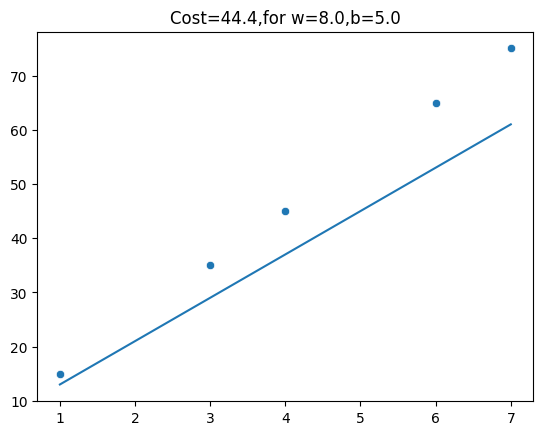

In [38]:
w=8.0
b=5.0
prediction=make_prediction(X,y,w=w,b=b)
sns.scatterplot(x=X, y=y)
plt.plot(X,prediction)
plt.title(f"Cost={compute_cost(X,y,w,b)},for w={w},b={b}")


## Compute Gradiant

In [69]:
def calculate_gradient(X, y, w, b):
  """Computes the gradient (direction to move) for w and b"""
  m = X.shape[0]
  dj_dw = 0.0 # Change needed for weight
  dj_db = 0.0 # Change needed for bias

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    # Multiply error by X[i] for the weight gradient
    dj_dw = dj_dw + (error * X[i])
    # The bias gradient is just the sum of errors
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [70]:
compute_gradiant(X,y,w=12,b=5)

(np.float64(44.4), np.float64(8.4))

## Gradient Decent

In [74]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize cost"""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.2f}, w: {w:0.2f}, b: {b:0.2f}")

  return w, b, cost_memo, iteration

In [77]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

Iteration 0: Cost 790.37, w: 2.43, b: 0.47
Iteration 100: Cost 0.61, w: 10.47, b: 2.56
Iteration 200: Cost 0.41, w: 10.38, b: 3.00
Iteration 300: Cost 0.28, w: 10.31, b: 3.36
Iteration 400: Cost 0.19, w: 10.26, b: 3.65
Iteration 500: Cost 0.13, w: 10.21, b: 3.90
Iteration 600: Cost 0.08, w: 10.17, b: 4.10
Iteration 700: Cost 0.06, w: 10.14, b: 4.26
Iteration 800: Cost 0.04, w: 10.12, b: 4.39
Iteration 900: Cost 0.03, w: 10.10, b: 4.50
Iteration 1000: Cost 0.02, w: 10.08, b: 4.59
Iteration 1100: Cost 0.01, w: 10.06, b: 4.66
Iteration 1200: Cost 0.01, w: 10.05, b: 4.72
Iteration 1300: Cost 0.01, w: 10.04, b: 4.77
Iteration 1400: Cost 0.00, w: 10.04, b: 4.82
Iteration 1500: Cost 0.00, w: 10.03, b: 4.85
Iteration 1600: Cost 0.00, w: 10.02, b: 4.88
Iteration 1700: Cost 0.00, w: 10.02, b: 4.90
Iteration 1800: Cost 0.00, w: 10.02, b: 4.92
Iteration 1900: Cost 0.00, w: 10.01, b: 4.93
Iteration 2000: Cost 0.00, w: 10.01, b: 4.94
Iteration 2100: Cost 0.00, w: 10.01, b: 4.95
Iteration 2200: Cost 

## Final Result and Prediction

C:\Users\fahmi\AppData\Local\Temp\ipykernel_42672\558164788.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


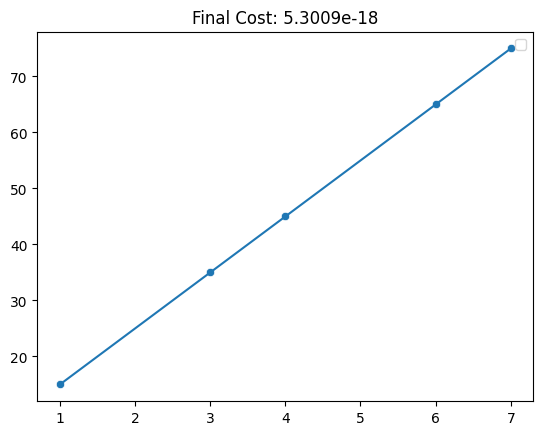

In [88]:
final_prediction = make_prediction(X,y,w_final,b_final)
sns.scatterplot(x=X,y=y)
plt.plot(X,final_prediction)
plt.title(f"Final Cost: {compute_cost(X,y,w_final,b_final):0.4e}")
plt.legend()
plt.show()

In [91]:
new_X =2
final_pred = w_final *new_X + b_final
print(f"For 2 years of experience salaray would be {final_pred:0.4f}")

For 2 years of experience salaray would be 25.0000


## Iteration vs Cost Graph

Text(0, 0.5, 'Cost')

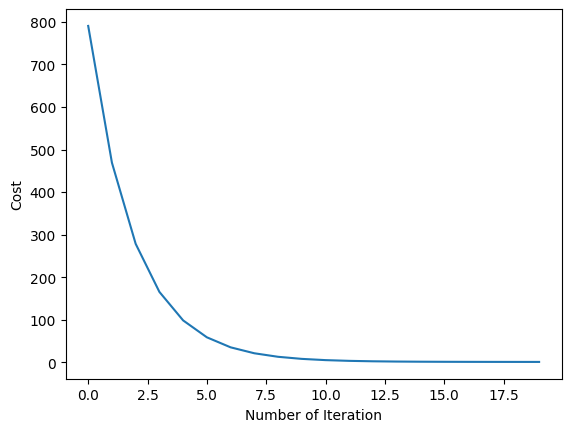

In [95]:
plt.plot(iteration[:20],cost_memo[:20])
plt.xlabel("Number of Iteration")
plt.ylabel("Cost")